# 02 — JSON to Binary Masks

 **Purpose:** Read the manifest from Notebook 1, convert each LabelMe tongue polygon
 into a binary PNG mask (tongue = 255, background = 0) at original image resolution.

 **This notebook does NOT:** resize images, train models, split data, or modify source folders.


# 1  Imports

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image, ImageDraw

print(f"pandas      {pd.__version__}")
print(f"PIL         {Image.__version__}")
print(f"numpy       {np.__version__}")
print(f"matplotlib  {matplotlib.__version__}")


pandas      2.3.3
PIL         10.4.0
numpy       2.4.4
matplotlib  3.10.0


# 2  Constants
OUTPUT_ROOT must match exactly what was used in Notebook 1.

In [2]:
OUTPUT_ROOT   = Path(r"D:\DIABETES\Segmentation_Dataset\Segmentation_Branch_Outputs")
MANIFEST_PATH = OUTPUT_ROOT / "01_manifest" / "segmentation_master_manifest.csv"
MASK_OUT_DIR  = OUTPUT_ROOT / "02_masks" / "binary_masks"
MANIFEST_OUT  = OUTPUT_ROOT / "01_manifest" / "segmentation_master_manifest_with_masks.csv"
AUDIT_OUT     = OUTPUT_ROOT / "04_visual_audits" / "02_mask_generation_visual_audit.png"

assert OUTPUT_ROOT.exists(),   f"OUTPUT_ROOT not found: {OUTPUT_ROOT}"
assert MANIFEST_PATH.exists(), f"Manifest not found: {MANIFEST_PATH}\nRun Notebook 1 first."
print(f"Manifest found: {MANIFEST_PATH}")

Manifest found: D:\DIABETES\Segmentation_Dataset\Segmentation_Branch_Outputs\01_manifest\segmentation_master_manifest.csv


# 3  Create Output Folders

In [3]:
for d in [MASK_OUT_DIR, OUTPUT_ROOT / "04_visual_audits"]:
    d.mkdir(parents=True, exist_ok=True)
    print(f"Ready: {d}")

Ready: D:\DIABETES\Segmentation_Dataset\Segmentation_Branch_Outputs\02_masks\binary_masks
Ready: D:\DIABETES\Segmentation_Dataset\Segmentation_Branch_Outputs\04_visual_audits


# 4  Load Manifest and Filter Usable Rows

In [4]:
df = pd.read_csv(MANIFEST_PATH)
print(f"Manifest loaded: {len(df)} total rows.")

usable = df[df["usable_for_mask_generation"] == True].copy()
print(f"Usable rows (will attempt mask generation): {len(usable)}")

assert len(usable) > 0, (
    "No usable rows in manifest. "
    "Check that Notebook 1 completed correctly and usable_for_mask_generation = True exists."
)

Manifest loaded: 5267 total rows.
Usable rows (will attempt mask generation): 5265


# 5  Helper Functions

In [5]:
def load_tongue_polygons(json_path: Path):
    """
    Parse a LabelMe JSON and return all valid tongue polygon point lists.

    A valid polygon has:
      - label == 'tongue' (case-insensitive, stripped)
      - shape_type == 'polygon'  OR  shape_type missing/None  (defensive guard)
      - len(points) >= 3

    Returns (list_of_point_lists, error_msg).
    error_msg is None on success.
    """
    try:
        with open(json_path, "r", encoding="utf-8") as f:
            data = json.load(f)
        shapes = data.get("shapes", [])
        polys = []
        for s in shapes:
            label      = s.get("label", "").strip().lower()
            shape_type = s.get("shape_type", "polygon")  # default to polygon if missing
            points     = s.get("points", [])
            if (
                label == "tongue"
                and shape_type in ("polygon", None, "")
                and len(points) >= 3
            ):
                # Convert to list of (x, y) int tuples for PIL
                polys.append([(int(round(p[0])), int(round(p[1]))) for p in points])
        return polys, None
    except json.JSONDecodeError as e:
        return [], f"json_decode_error: {e}"
    except Exception as e:
        return [], f"json_read_error: {e}"


def get_image_size(image_path: Path, fallback_w=None, fallback_h=None):
    """
    Return (width, height) of image.
    Uses PIL header-only read. Falls back to (fallback_w, fallback_h) on error.
    """
    try:
        with Image.open(image_path) as img:
            return img.size
    except Exception:
        return fallback_w, fallback_h


def generate_mask(width: int, height: int, polygon_list: list) -> Image.Image:
    """
    Create a binary mask image of size (width, height).
    Fills all polygons in polygon_list with 255 (tongue area).
    Background is 0.
    Returns a PIL Image in mode 'L'.
    """
    mask = Image.new("L", (width, height), 0)
    draw = ImageDraw.Draw(mask)
    for poly in polygon_list:
        draw.polygon(poly, fill=255)
    return mask


def classify_ratio_warning(ratio: float) -> str:
    """
    Return a warning label based on mask foreground ratio.
    'suspicious_small_mask' : ratio < 0.02
    'suspicious_large_mask' : ratio > 0.95
    'none'                  : ratio is within expected range
    """
    if ratio < 0.02:
        return "suspicious_small_mask"
    if ratio > 0.95:
        return "suspicious_large_mask"
    return "none"


# smoke tests
assert classify_ratio_warning(0.01)  == "suspicious_small_mask"
assert classify_ratio_warning(0.96)  == "suspicious_large_mask"
assert classify_ratio_warning(0.15)  == "none"
print("Helper smoke tests passed.")

Helper smoke tests passed.


# 6  Generate Binary Masks

 For each usable row:
 - open the JSON, extract tongue polygons
 - create a blank mask at original image size
 - fill all tongue polygons with 255
 - save as `<base_name>_mask.png`
 - collect validation metrics

 On failure for any individual sample: log the error and continue.
 **Source folders are not touched.**


In [6]:
mask_records = []   # one dict per usable row

for _, row in usable.iterrows():

    base_name   = Path(row["image_path"]).stem   # e.g. '4_1'
    mask_fname  = base_name + "_mask.png"
    mask_path   = MASK_OUT_DIR / mask_fname

    # --- (a) determine image dimensions ---
    # Prefer stored values; fall back to re-opening the image.
    img_w = row.get("image_width")
    img_h = row.get("image_height")
    if pd.isna(img_w) or pd.isna(img_h):
        img_w, img_h = get_image_size(Path(row["image_path"]))

    if img_w is None or img_h is None:
        mask_records.append({
            "sample_id"             : row["sample_id"],
            "mask_path"             : "",
            "mask_created"          : False,
            "mask_width"            : None,
            "mask_height"           : None,
            "mask_unique_values"    : "",
            "mask_foreground_pixels": None,
            "mask_foreground_ratio" : None,
            "mask_valid_binary"     : False,
            "mask_ratio_warning"    : "none",
            "mask_error"            : "image_read_error",
        })
        print(f"  SKIP (image_read_error): {row['image_filename']}")
        continue

    img_w, img_h = int(img_w), int(img_h)

    # --- (b) load tongue polygons from JSON ---
    polys, poly_err = load_tongue_polygons(Path(row["json_path"]))

    if poly_err:
        mask_records.append({
            "sample_id"             : row["sample_id"],
            "mask_path"             : "",
            "mask_created"          : False,
            "mask_width"            : None,
            "mask_height"           : None,
            "mask_unique_values"    : "",
            "mask_foreground_pixels": None,
            "mask_foreground_ratio" : None,
            "mask_valid_binary"     : False,
            "mask_ratio_warning"    : "none",
            "mask_error"            : poly_err,
        })
        print(f"  SKIP ({poly_err}): {row['image_filename']}")
        continue

    if len(polys) == 0:
        # This should not happen for usable rows, but guard defensively.
        mask_records.append({
            "sample_id"             : row["sample_id"],
            "mask_path"             : "",
            "mask_created"          : False,
            "mask_width"            : None,
            "mask_height"           : None,
            "mask_unique_values"    : "",
            "mask_foreground_pixels": None,
            "mask_foreground_ratio" : None,
            "mask_valid_binary"     : False,
            "mask_ratio_warning"    : "none",
            "mask_error"            : "no_tongue_polygon_at_generation_time",
        })
        print(f"  SKIP (no polygon found at generation time): {row['image_filename']}")
        continue

    # --- (c) generate mask ---
    try:
        mask_img = generate_mask(img_w, img_h, polys)
        mask_img.save(str(mask_path))
        mask_created = True
    except Exception as e:
        mask_records.append({
            "sample_id"             : row["sample_id"],
            "mask_path"             : "",
            "mask_created"          : False,
            "mask_width"            : None,
            "mask_height"           : None,
            "mask_unique_values"    : "",
            "mask_foreground_pixels": None,
            "mask_foreground_ratio" : None,
            "mask_valid_binary"     : False,
            "mask_ratio_warning"    : "none",
            "mask_error"            : f"mask_save_error: {e}",
        })
        print(f"  SKIP (mask_save_error): {row['image_filename']}: {e}")
        continue

    # --- (d) validate mask ---
    mask_arr        = np.array(mask_img)
    unique_vals     = sorted(np.unique(mask_arr).tolist())
    fg_pixels       = int((mask_arr == 255).sum())
    total_pixels    = img_w * img_h
    fg_ratio        = fg_pixels / total_pixels if total_pixels > 0 else 0.0
    is_valid_binary = (
        set(unique_vals).issubset({0, 255})
        and fg_pixels > 0
        and mask_path.exists()
    )
    ratio_warning   = classify_ratio_warning(fg_ratio)

    mask_records.append({
        "sample_id"             : row["sample_id"],
        "mask_path"             : str(mask_path),
        "mask_created"          : True,
        "mask_width"            : img_w,
        "mask_height"           : img_h,
        "mask_unique_values"    : str(unique_vals),
        "mask_foreground_pixels": fg_pixels,
        "mask_foreground_ratio" : round(fg_ratio, 6),
        "mask_valid_binary"     : is_valid_binary,
        "mask_ratio_warning"    : ratio_warning,
        "mask_error"            : "none",
    })

print(f"\nMask generation loop complete.  {len(mask_records)} rows processed.")


Mask generation loop complete.  5265 rows processed.


# 7  Build Mask DataFrame and Merge with Manifest

In [7]:
mask_df = pd.DataFrame(mask_records)

# Merge on sample_id — left join keeps all usable rows.
df_with_masks = usable.merge(mask_df, on="sample_id", how="left")

assert len(df_with_masks) == len(usable), (
    f"Row count mismatch after merge: {len(df_with_masks)} vs {len(usable)}"
)
print(f"Merged DataFrame shape: {df_with_masks.shape}")
df_with_masks.head()

Merged DataFrame shape: (5265, 27)


,sample_id,patient_id,image_id,image_path,json_path,segmented_image_path,image_filename,json_filename,segmented_image_filename,image_width,...,mask_path,mask_created,mask_width,mask_height,mask_unique_values,mask_foreground_pixels,mask_foreground_ratio,mask_valid_binary,mask_ratio_warning,mask_error
0,00000_1000_1,1000.0,1.0,D:\DIABETES\Segmentation_Dataset\Standardized_...,D:\DIABETES\Segmentation_Dataset\LabelMe_JSON\...,D:\DIABETES\Segmentation_Dataset\Img\1000_1.png,1000_1.jpg,1000_1.json,1000_1.png,512,...,D:\DIABETES\Segmentation_Dataset\Segmentation_...,True,512,512,"[0, 255]",77582,0.295952,True,none,none
1,00001_1000_2,1000.0,2.0,D:\DIABETES\Segmentation_Dataset\Standardized_...,D:\DIABETES\Segmentation_Dataset\LabelMe_JSON\...,D:\DIABETES\Segmentation_Dataset\Img\1000_2.png,1000_2.jpg,1000_2.json,1000_2.png,512,...,D:\DIABETES\Segmentation_Dataset\Segmentation_...,True,512,512,"[0, 255]",111640,0.425873,True,none,none
2,00002_1001_1,1001.0,1.0,D:\DIABETES\Segmentation_Dataset\Standardized_...,D:\DIABETES\Segmentation_Dataset\LabelMe_JSON\...,D:\DIABETES\Segmentation_Dataset\Img\1001_1.png,1001_1.jpg,1001_1.json,1001_1.png,512,...,D:\DIABETES\Segmentation_Dataset\Segmentation_...,True,512,512,"[0, 255]",79430,0.303001,True,none,none
3,00003_1001_2,1001.0,2.0,D:\DIABETES\Segmentation_Dataset\Standardized_...,D:\DIABETES\Segmentation_Dataset\LabelMe_JSON\...,D:\DIABETES\Segmentation_Dataset\Img\1001_2.png,1001_2.jpg,1001_2.json,1001_2.png,512,...,D:\DIABETES\Segmentation_Dataset\Segmentation_...,True,512,512,"[0, 255]",80796,0.308212,True,none,none
4,00004_1002_1,1002.0,1.0,D:\DIABETES\Segmentation_Dataset\Standardized_...,D:\DIABETES\Segmentation_Dataset\LabelMe_JSON\...,D:\DIABETES\Segmentation_Dataset\Img\1002_1.png,1002_1.jpg,1002_1.json,1002_1.png,512,...,D:\DIABETES\Segmentation_Dataset\Segmentation_...,True,512,512,"[0, 255]",102071,0.389370,True,none,none


# 8  Save Updated Manifest

In [8]:
df_with_masks.to_csv(MANIFEST_OUT, index=False)
print(f"Updated manifest saved -> {MANIFEST_OUT}")
assert MANIFEST_OUT.exists(), "ERROR: updated manifest was not created."

Updated manifest saved -> D:\DIABETES\Segmentation_Dataset\Segmentation_Branch_Outputs\01_manifest\segmentation_master_manifest_with_masks.csv


# 9  Summary Statistics

In [9]:
n_attempted       = len(mask_records)
n_created         = int(mask_df["mask_created"].sum())
n_failed          = n_attempted - n_created
n_invalid         = int((~mask_df["mask_valid_binary"]).sum())
n_small_warn      = int((mask_df["mask_ratio_warning"] == "suspicious_small_mask").sum())
n_large_warn      = int((mask_df["mask_ratio_warning"] == "suspicious_large_mask").sum())

print("=" * 52)
print(f"  Usable rows attempted        : {n_attempted}")
print(f"  Masks successfully created   : {n_created}")
print(f"  Masks failed (see errors)    : {n_failed}")
print(f"  Invalid masks (bad binary)   : {n_invalid}")
print(f"  Warning: suspicious small    : {n_small_warn}")
print(f"  Warning: suspicious large    : {n_large_warn}")
print("=" * 52)

# Show failed rows for inspection
failed = mask_df[~mask_df["mask_created"]]
if len(failed) > 0:
    print("\nFailed samples:")
    print(failed[["sample_id", "mask_error"]].to_string(index=False))

# Show warning rows
small_warn_rows = mask_df[mask_df["mask_ratio_warning"] == "suspicious_small_mask"]
large_warn_rows = mask_df[mask_df["mask_ratio_warning"] == "suspicious_large_mask"]
if len(small_warn_rows) > 0:
    print("\nSuspicious SMALL masks (ratio < 0.02):")
    print(small_warn_rows[["sample_id", "mask_foreground_ratio"]].to_string(index=False))
if len(large_warn_rows) > 0:
    print("\nSuspicious LARGE masks (ratio > 0.95):")
    print(large_warn_rows[["sample_id", "mask_foreground_ratio"]].to_string(index=False))

  Usable rows attempted        : 5265
  Masks successfully created   : 5265
  Masks failed (see errors)    : 0
  Invalid masks (bad binary)   : 0


# 10  Visual Audit — 12 Random Generated Masks

 Four columns per row:
 1. Original image
 2. Binary mask (grayscale)
 3. Mask overlaid on original (semi-transparent red)
 4. Pre-existing segmented image (if available), else placeholder

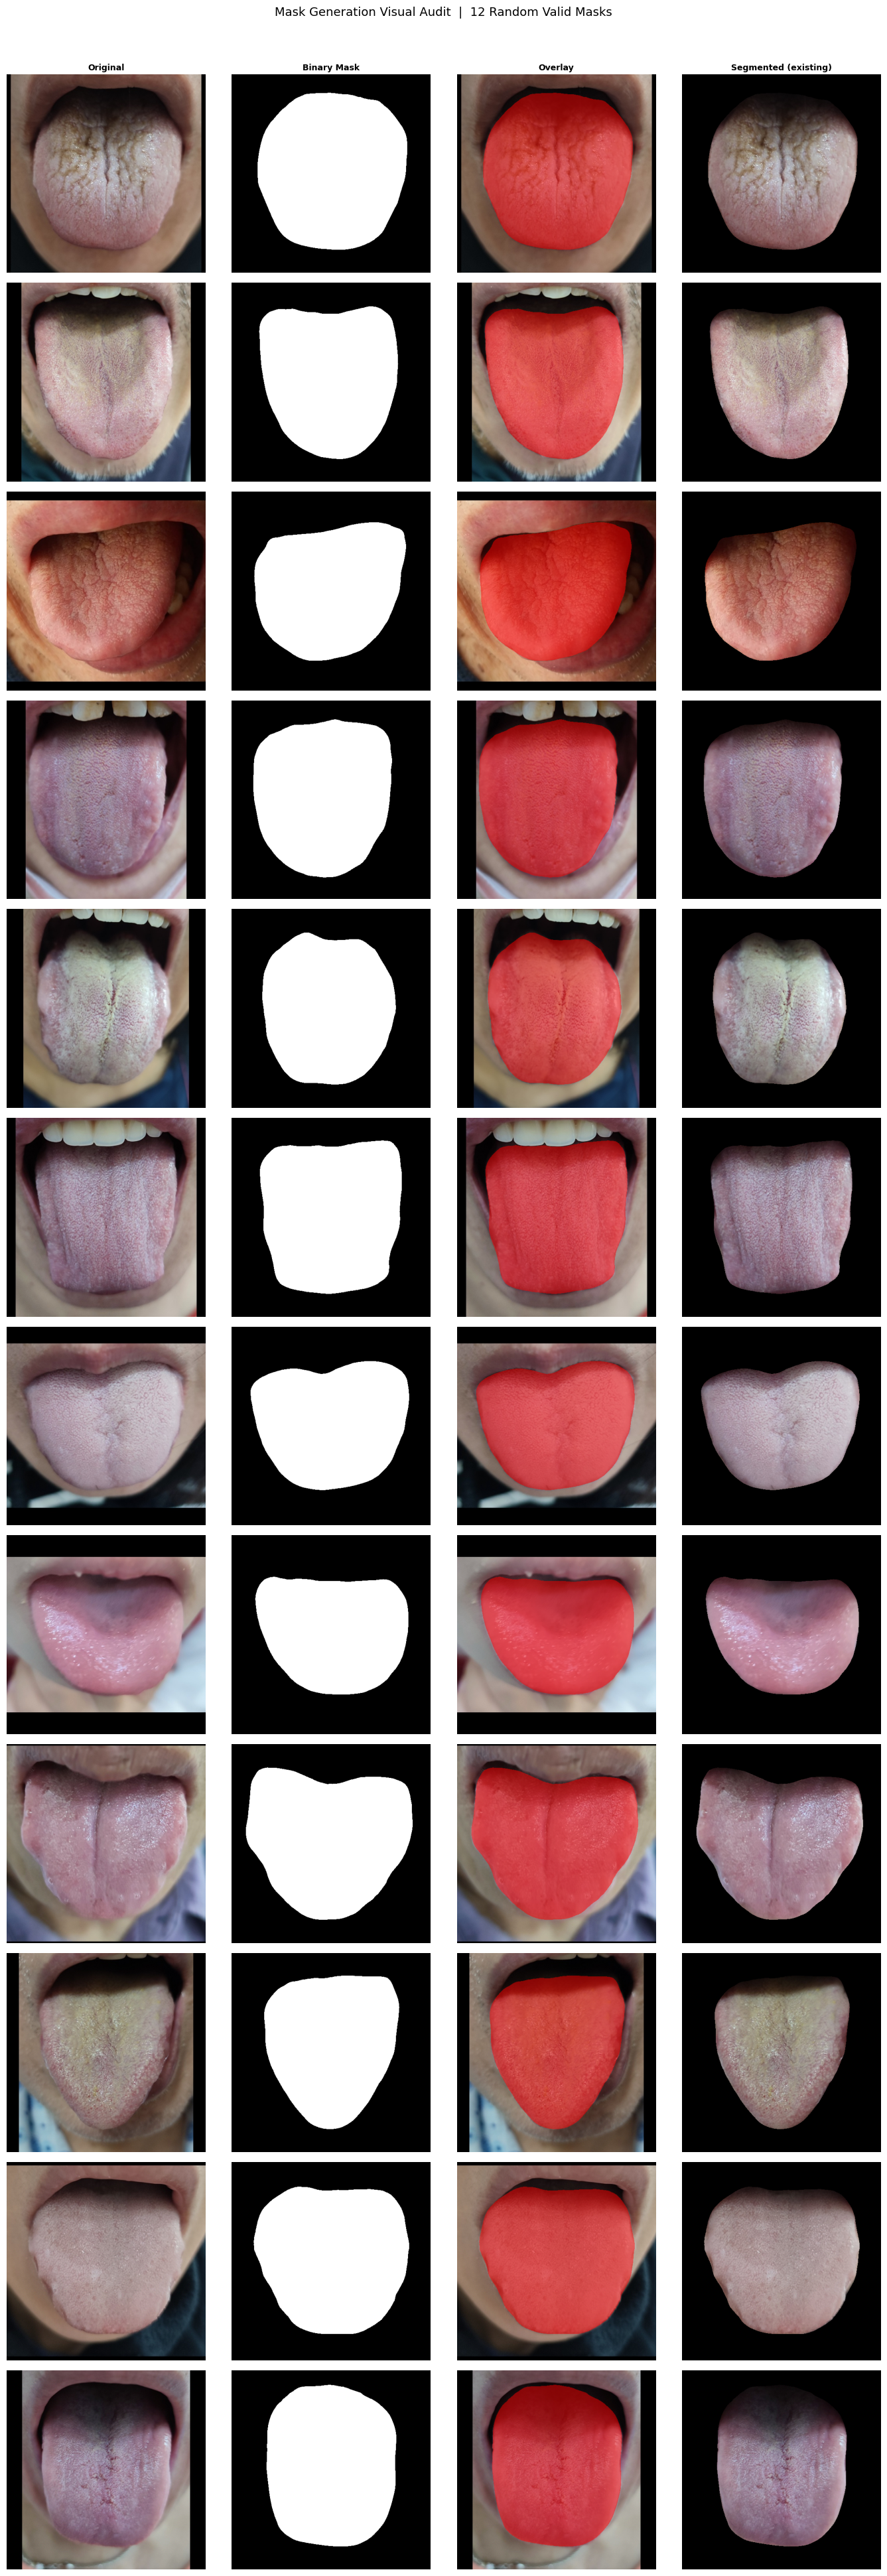

Visual audit saved -> D:\DIABETES\Segmentation_Dataset\Segmentation_Branch_Outputs\04_visual_audits\02_mask_generation_visual_audit.png


In [10]:
valid_masks = df_with_masks[df_with_masks["mask_created"] == True].reset_index(drop=True)

if len(valid_masks) == 0:
    print("No valid masks to audit — visual audit skipped.")
else:
    n_samples = min(12, len(valid_masks))
    sampled   = valid_masks.sample(n=n_samples, random_state=42).reset_index(drop=True)

    n_cols = 4
    fig, axes = plt.subplots(n_samples, n_cols,
                              figsize=(14, n_samples * 3.2),
                              squeeze=False)

    col_labels = ["Original", "Binary Mask", "Overlay", "Segmented (existing)"]
    for col_idx, lbl in enumerate(col_labels):
        axes[0, col_idx].set_title(lbl, fontsize=9, fontweight="bold", pad=4)

    for i, row in sampled.iterrows():

        img_path  = Path(row["image_path"])
        mask_path = Path(row["mask_path"])

        # Load orignal and mask — both should exist for valid rows
        try:
            orig_img  = Image.open(img_path).convert("RGB")
            orig_arr  = np.array(orig_img)
        except Exception as e:
            orig_arr = None
            orig_load_err = str(e)

        try:
            mask_img = Image.open(mask_path).convert("L")
            mask_arr = np.array(mask_img)
        except Exception as e:
            mask_arr = None

        # Col 0: original
        ax = axes[i, 0]
        if orig_arr is not None:
            ax.imshow(orig_arr)
        else:
            ax.text(0.5, 0.5, f"Load error:\n{orig_load_err}",
                    ha="center", va="center", color="red",
                    transform=ax.transAxes, fontsize=7)
        ax.set_ylabel(f"{row['image_filename']}\nPID={row['patient_id']}",
                      fontsize=6, rotation=0, labelpad=60, va="center")
        ax.axis("off")

        # Col 1: binary mask
        ax = axes[i, 1]
        if mask_arr is not None:
            ax.imshow(mask_arr, cmap="gray", vmin=0, vmax=255)
            ax.set_xlabel(
                f"fg={row['mask_foreground_ratio']:.3f}  {row['mask_ratio_warning']}",
                fontsize=6)
        else:
            ax.text(0.5, 0.5, "Mask load error",
                    ha="center", va="center", color="red",
                    transform=ax.transAxes, fontsize=7)
        ax.axis("off")

        # Col 2: overlay (red tongue region on original)
        ax = axes[i, 2]
        if orig_arr is not None and mask_arr is not None:
            overlay = orig_arr.copy().astype(np.float32)
            tongue_px = (mask_arr == 255)
            overlay[tongue_px, 0] = np.clip(overlay[tongue_px, 0] * 0.5 + 127, 0, 255)
            overlay[tongue_px, 1] = np.clip(overlay[tongue_px, 1] * 0.5, 0, 255)
            overlay[tongue_px, 2] = np.clip(overlay[tongue_px, 2] * 0.5, 0, 255)
            ax.imshow(overlay.astype(np.uint8))
        else:
            ax.text(0.5, 0.5, "Cannot overlay\n(missing data)",
                    ha="center", va="center", color="gray",
                    transform=ax.transAxes, fontsize=7)
        ax.axis("off")

        # Col 3: pre-existing segmented image or placeholder
        ax = axes[i, 3]
        seg_exists = row.get("segmented_image_exists", False)
        seg_path   = row.get("segmented_image_path", "")
        if seg_exists and seg_path:
            try:
                ax.imshow(np.array(Image.open(seg_path)))
            except Exception as e:
                ax.text(0.5, 0.5, f"Load error:\n{e}",
                        ha="center", va="center", color="red",
                        transform=ax.transAxes, fontsize=7)
        else:
            ax.set_facecolor("#111111")
            ax.text(0.5, 0.5, "Unavailable",
                    ha="center", va="center", color="gray",
                    transform=ax.transAxes, fontsize=8)
        ax.axis("off")

    fig.suptitle(
        f"Mask Generation Visual Audit  |  {n_samples} Random Valid Masks",
        fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig(AUDIT_OUT, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"Visual audit saved -> {AUDIT_OUT}")

# Notebook Complete

 | Output | Location |
 |--------|----------|
 | Binary masks (PNG) | `02_masks/binary_masks/<base_name>_mask.png` |
 | Updated manifest   | `01_manifest/segmentation_master_manifest_with_masks.csv` |
 | Visual audit       | `04_visual_audits/02_mask_generation_visual_audit.png` |

 **Mask properties enforced:**
 - Binary 0 / 255 only
 - Generated at original image resolution (no resizing — resize happens in PyTorch dataset loader)
 - All valid tongue polygons per JSON are filled

 **Source folders were not modified.**
 **Do not train a model yet.**